# FVCOM Nest Forcing File Generation Tutorial

This tutorial demonstrates how to create FVCOM nest forcing files using PyFVCOM2. We'll work through the complete workflow from reading CMEMS oceanographic data to generating the final forcing file with visualization.

## Overview

FVCOM nested grids require boundary forcing data to drive the model. This tutorial shows how to:

1. Set up the required data paths and parameters
2. Create FVCOM grid objects
3. Read and interpolate CMEMS oceanographic data
4. Generate nest forcing files
5. Visualize the results

## Prerequisites

- PyFVCOM2 installed with all dependencies
- CMEMS oceanographic data files
- FVCOM grid files (grid definition, open boundary, sigma levels)

## 1. Import Required Libraries

First, we import all the necessary libraries for data processing, interpolation, and visualization:

In [1]:
from datetime import datetime, timedelta
import os
import pathlib

# PyFVCOM2 imports
from pyfvcom2.file_utils import find_files
from pyfvcom2.date_utils import create_datetime_array
from pyfvcom2.grid import create_grid
from pyfvcom2.cmems_reader import CMEMSReader
from pyfvcom2.interpolation import CMEMSInterpolator
from pyfvcom2.nest import NestManager

# Plotting imports
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.colors import Normalize
from netCDF4 import Dataset
from pyfvcom2.plotting import FVCOMPlotter, CMEMSPlotter, create_figure

## 2. Configuration and Setup

Define all the required paths and parameters for the nest forcing generation:

In [2]:
# CMEMS data configuration
cmems_data_dir = '/data/sthenno1/scratch/jcl/wcoof/data/CMEMS_rolling'
product_name_2d = 'cmems_mod_nws_phy_anfc_0.027deg-2D_PT1H-m'
product_name_3d = 'cmems_mod_nws_phy_anfc_0.027deg-3D_PT1H-m'

# FVCOM grid configuration
home_dir = os.path.expanduser('~/code/git/pyfvcom2')
resources_dir = f'{home_dir}/resources'
grid_file = f'{resources_dir}/tamar_v2_grd.dat'
obc_file = f'{resources_dir}/tamar_v2_obc.dat'
sigma_file = f'{resources_dir}/sigma_gen.dat'

print(f"CMEMS data directory: {cmems_data_dir}")
print(f"Grid file: {grid_file}")
print(f"Open boundary file: {obc_file}")
print(f"Sigma file: {sigma_file}")

CMEMS data directory: /data/sthenno1/scratch/jcl/wcoof/data/CMEMS_rolling
Grid file: /users/modellers/jcl/code/git/pyfvcom2/resources/tamar_v2_grd.dat
Open boundary file: /users/modellers/jcl/code/git/pyfvcom2/resources/tamar_v2_obc.dat
Sigma file: /users/modellers/jcl/code/git/pyfvcom2/resources/sigma_gen.dat


## 3. Time Period Definition

Set up the time period for which we want to generate forcing data:

In [3]:
# Define the simulation time period
start_date_time = datetime.strptime("20250614", "%Y%m%d")
end_date_time = datetime.strptime("2025061402", "%Y%m%d%H")

# Create array of hourly datetime objects
date_times = create_datetime_array(start_date_time, end_date_time, timedelta(hours=1))

print(f"Start time: {start_date_time}")
print(f"End time: {end_date_time}")
print(f"Number of time steps: {len(date_times)}")
print(f"Time step interval: 1 hour")

Start time: 2025-06-14 00:00:00
End time: 2025-06-14 02:00:00
Number of time steps: 3
Time step interval: 1 hour


## 4. FVCOM Grid Creation

Load the FVCOM grid and create a Grid object with all necessary components:

In [4]:
# Create FVCOM grid object
fvcom_grid = create_grid(
    grid_file, 
    mesh_type='fvcom', 
    sigma_file=sigma_file,
    coordinate_system='cartesian', 
    epsg_code='32630', 
    obc_filename=obc_file
)

print(f"Grid loaded successfully!")
print(f"Number of nodes: {fvcom_grid.n_nodes}")
print(f"Number of elements: {fvcom_grid.n_elements}")
print(f"Number of sigma levels: {fvcom_grid.n_sigma_levels}")
print(f"Longitude range: [{fvcom_grid.lon.min():.4f}, {fvcom_grid.lon.max():.4f}]")
print(f"Latitude range: [{fvcom_grid.lat.min():.4f}, {fvcom_grid.lat.max():.4f}]")

Grid loaded successfully!
Number of nodes: 39910
Number of elements: 75400
Number of sigma levels: 25
Longitude range: [-4.8078, -3.8044]
Latitude range: [49.7212, 50.5190]


## 5. Nest Manager Setup

Create the NestManager which handles the interpolation and forcing file generation:

In [5]:
# Create NestManager with linear interpolation weights
nest_manager = NestManager(
    fvcom_grid, 
    num_grid_bands=2, 
    weights_calculation_method='linear'
)

# Set the time period
nest_manager.set_dates(date_times)

print("NestManager created successfully!")
print(f"Number of grid bands: 2")
print(f"Interpolation method: linear")

Updating NestManager dates and purging old forcing data for the previous dates.
NestManager created successfully!
Number of grid bands: 2
Interpolation method: linear


## 6. 2D Data Processing (Sea Surface Height)

Process the 2D oceanographic data, starting with sea surface height (zeta):

In [6]:
# Find 2D CMEMS files
data_dir_2d = pathlib.Path(cmems_data_dir, product_name_2d)
files_2d = find_files(
    data_dir_2d, 
    product_name_2d, 
    start_date_time, 
    end_date_time, 
    tolerance_hours=1
)

print(f"Found {len(files_2d)} 2D CMEMS files:")
for i, file in enumerate(files_2d[:3]):  # Show first 3 files
    print(f"  {i+1}: {file}")
if len(files_2d) > 3:
    print(f"  ... and {len(files_2d)-3} more files")

Found 1 2D CMEMS files:
  1: /data/sthenno1/scratch/jcl/wcoof/data/CMEMS_rolling/cmems_mod_nws_phy_anfc_0.027deg-2D_PT1H-m/cmems_mod_nws_phy_anfc_0.027deg-2D_PT1H-m_20250614_20250614.nc


In [7]:
# Create CMEMS reader for 2D data
cmems_reader_2d = CMEMSReader(files_2d, reference_var_name='zos')

# Create interpolator
cmems_interpolator_2d = CMEMSInterpolator(cmems_reader_2d)

# Add zeta (sea surface height) forcing variable
nest_manager.add_forcing_data(cmems_interpolator_2d, 'zeta', grid_position='node')

print("2D data processing complete!")
print("Added forcing variable: zeta (sea surface height)")

Accessing CMEMS metadata from: /data/sthenno1/scratch/jcl/wcoof/data/CMEMS_rolling/cmems_mod_nws_phy_anfc_0.027deg-2D_PT1H-m/cmems_mod_nws_phy_anfc_0.027deg-2D_PT1H-m_20250614_20250614.nc
Depth dimension variable name depth not found in CMEMS file /data/sthenno1/scratch/jcl/wcoof/data/CMEMS_rolling/cmems_mod_nws_phy_anfc_0.027deg-2D_PT1H-m/cmems_mod_nws_phy_anfc_0.027deg-2D_PT1H-m_20250614_20250614.nc.
Assuming the dataset includes 2D variables only.
Using dimension variable names:
  Time: time
  Longitude: longitude
  Latitude: latitude
Using reference variable zos.
Interpolating CMEMS zos to FVCOM grid.
Interpolating CMEMS zos to FVCOM grid for date: 2025-06-14 00:00:00.
Interpolating CMEMS zos to FVCOM grid for date: 2025-06-14 01:00:00.
Interpolating CMEMS zos to FVCOM grid for date: 2025-06-14 02:00:00.
2D data processing complete!
Added forcing variable: zeta (sea surface height)


## 7. 3D Data Processing (Currents, Temperature, Salinity)

Process the 3D oceanographic data including currents, temperature, and salinity:

In [8]:
# Find 3D CMEMS files
data_dir_3d = pathlib.Path(cmems_data_dir, product_name_3d)
files_3d = find_files(
    data_dir_3d, 
    product_name_3d, 
    start_date_time, 
    end_date_time, 
    tolerance_hours=1
)

print(f"Found {len(files_3d)} 3D CMEMS files:")
for i, file in enumerate(files_3d[:3]):  # Show first 3 files
    print(f"  {i+1}: {file}")
if len(files_3d) > 3:
    print(f"  ... and {len(files_3d)-3} more files")

Found 1 3D CMEMS files:
  1: /data/sthenno1/scratch/jcl/wcoof/data/CMEMS_rolling/cmems_mod_nws_phy_anfc_0.027deg-3D_PT1H-m/cmems_mod_nws_phy_anfc_0.027deg-3D_PT1H-m_20250614_20250614.nc


In [9]:
# Create CMEMS reader for 3D data
cmems_reader_3d = CMEMSReader(files_3d, reference_var_name='so')

# Create interpolator
cmems_interpolator_3d = CMEMSInterpolator(cmems_reader_3d)

# Add 3D forcing variables
forcing_variables = [
    ('u', 'element'),      # u-velocity at element centers
    ('v', 'element'),      # v-velocity at element centers 
    ('temp', 'node'),      # temperature at nodes
    ('salinity', 'node')   # salinity at nodes
]

print("Adding 3D forcing variables:")
for fvcom_var, position in forcing_variables:
    nest_manager.add_forcing_data(cmems_interpolator_3d, fvcom_var, grid_position=position)
    print(f"  {fvcom_var} (at {position}s)")

print("3D data processing complete!")

Accessing CMEMS metadata from: /data/sthenno1/scratch/jcl/wcoof/data/CMEMS_rolling/cmems_mod_nws_phy_anfc_0.027deg-3D_PT1H-m/cmems_mod_nws_phy_anfc_0.027deg-3D_PT1H-m_20250614_20250614.nc
Using dimension variable names:
  Time: time
  Depth: depth
  Longitude: longitude
  Latitude: latitude
Using reference variable so.
Adding 3D forcing variables:
Interpolating CMEMS uo to FVCOM grid.
Interpolating CMEMS uo to FVCOM grid for date: 2025-06-14 00:00:00.
Interpolating CMEMS uo to FVCOM grid for date: 2025-06-14 01:00:00.
Interpolating CMEMS uo to FVCOM grid for date: 2025-06-14 02:00:00.
  u (at elements)
Interpolating CMEMS vo to FVCOM grid.
Interpolating CMEMS vo to FVCOM grid for date: 2025-06-14 00:00:00.
Interpolating CMEMS vo to FVCOM grid for date: 2025-06-14 01:00:00.
Interpolating CMEMS vo to FVCOM grid for date: 2025-06-14 02:00:00.
  v (at elements)
Interpolating CMEMS thetao to FVCOM grid.
Interpolating CMEMS thetao to FVCOM grid for date: 2025-06-14 00:00:00.
Interpolating CM

## 8. Generate Nest Forcing File

Create the final NetCDF forcing file that FVCOM will use:

In [10]:
# Define output filename
file_name = 'tamar_v2_nest_forcing.nc'

# Generate the nest forcing file (nest_type=3 for 3D nesting)
nest_manager.create_forcing_file(file_name, nest_type=3)

print(f"Nest forcing file created: {file_name}")
print(f"File size: {os.path.getsize(file_name) / (1024*1024):.1f} MB")

Nest forcing file created: tamar_v2_nest_forcing.nc
File size: 0.4 MB


## 9. Visualization Setup

Set up the plotting objects and load the generated forcing file for visualization:

In [11]:
# Open the generated nest forcing file
nest_ds = Dataset(file_name)

# Create plotting objects
reference_cmems_file = files_2d[0]
cmems_plotter = CMEMSPlotter(reference_cmems_file)
fvcom_plotter = FVCOMPlotter(fvcom_grid)

print("Visualization setup complete!")
print(f"Using reference CMEMS file: {reference_cmems_file}")

Visualization setup complete!
Using reference CMEMS file: /data/sthenno1/scratch/jcl/wcoof/data/CMEMS_rolling/cmems_mod_nws_phy_anfc_0.027deg-2D_PT1H-m/cmems_mod_nws_phy_anfc_0.027deg-2D_PT1H-m_20250614_20250614.nc


## 10. Sea Surface Height Visualization

Visualize the sea surface height data from CMEMS and the interpolated values at FVCOM boundary nodes:

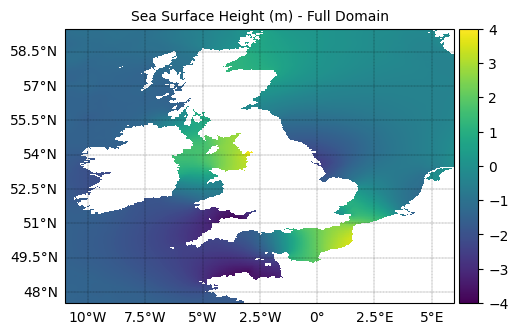

In [12]:
# Define colormap and normalization for zeta
cmap = plt.cm.viridis
norm = Normalize(vmin=-4, vmax=4)

# Plot 1: Full domain sea surface height
fig1, ax1 = create_figure(
    figure_size=(14, 12), 
    projection=ccrs.PlateCarree(), 
    axis_position=[0.125, 0.1, 0.75, 0.8]
)

# Plot CMEMS zeta data
zeta_cmems = cmems_reader_2d.get_var('zos', target_datetime=start_date_time).squeeze()
cmems_plotter.plot_field(
    ax=ax1,
    field=zeta_cmems,
    configure=True,
    cmap=cmap,
    norm=norm,
    add_colour_bar=True
)

ax1.set_xlabel('Longitude (°E)', fontsize=10)
ax1.set_ylabel('Latitude (°N)', fontsize=10)
ax1.set_title('Sea Surface Height (m) - Full Domain', fontsize=10)

plt.show()

Plotting in geographic coordinates but no transform supplied. Using PlateCarree. You can override this by supplying a transform argument.


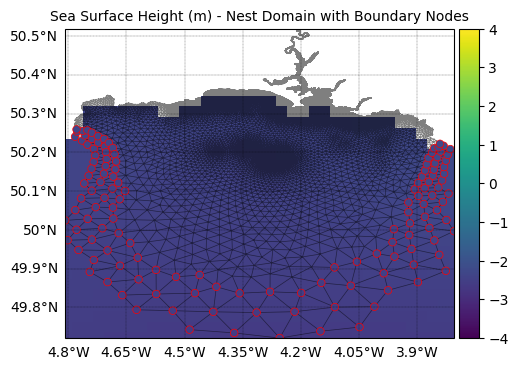

In [13]:
# Plot 2: Nest domain with boundary nodes
fig2, ax2 = create_figure(
    figure_size=(14, 12), 
    projection=ccrs.PlateCarree(), 
    axis_position=[0.125, 0.1, 0.75, 0.8]
)

# Plot CMEMS zeta zoomed to nest area
cmems_plotter.plot_field(
    ax=ax2,
    field=zeta_cmems,
    configure=True,
    cmap=cmap,
    norm=norm,
    extents=[fvcom_grid.lon.min(), fvcom_grid.lon.max(), 
             fvcom_grid.lat.min(), fvcom_grid.lat.max()],
    add_colour_bar=True
)

# Overlay FVCOM grid
fvcom_plotter.draw_grid(ax=ax2, color='black', linewidth=0.5, alpha=0.5)

# Read and plot interpolated boundary values
lons_nest = nest_ds.variables['lon'][:]
lats_nest = nest_ds.variables['lat'][:]
zeta_nest = nest_ds.variables['zeta'][0, :]  # First time step

fvcom_plotter.scatter(
    ax2, lons_nest, lats_nest, c=zeta_nest,
    s=30, cmap=cmap, norm=norm, 
    edgecolor='r', linewidth=0.5
)

ax2.set_xlabel('Longitude (°E)', fontsize=10)
ax2.set_ylabel('Latitude (°N)', fontsize=10)
ax2.set_title('Sea Surface Height (m) - Nest Domain with Boundary Nodes', fontsize=10)

plt.show()

## 11. Current Speed Visualization

Visualize the current speed data from CMEMS and the interpolated values at FVCOM boundary elements:

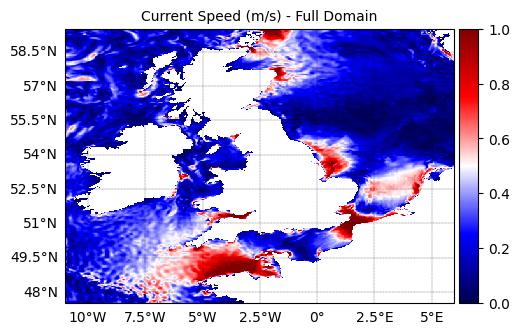

In [14]:
# Define colormap and normalization for current speed
cmap = plt.cm.seismic
norm = Normalize(vmin=0, vmax=1)

# Calculate current speed from u and v components
u_cmems = cmems_reader_3d.get_var('uo', target_datetime=start_date_time, depth_index=0)[:, :].squeeze()
v_cmems = cmems_reader_3d.get_var('vo', target_datetime=start_date_time, depth_index=0)[:, :].squeeze()
current_speed_cmems = (u_cmems**2 + v_cmems**2)**0.5

# Plot 3: Full domain current speed
fig3, ax3 = create_figure(
    figure_size=(14, 12), 
    projection=ccrs.PlateCarree(), 
    axis_position=[0.125, 0.1, 0.75, 0.8]
)

cmems_plotter.plot_field(
    ax=ax3,
    field=current_speed_cmems,
    configure=True,
    cmap=cmap,
    norm=norm,
    add_colour_bar=True
)

ax3.set_xlabel('Longitude (°E)', fontsize=10)
ax3.set_ylabel('Latitude (°N)', fontsize=10)
ax3.set_title('Current Speed (m/s) - Full Domain', fontsize=10)

plt.show()

Plotting in geographic coordinates but no transform supplied. Using PlateCarree. You can override this by supplying a transform argument.


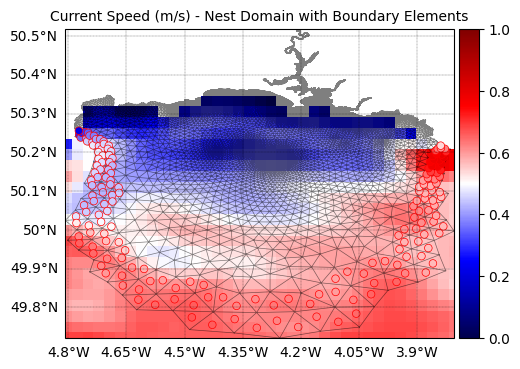

In [15]:
# Plot 4: Nest domain current speed with boundary elements
fig4, ax4 = create_figure(
    figure_size=(14, 12), 
    projection=ccrs.PlateCarree(), 
    axis_position=[0.125, 0.1, 0.75, 0.8]
)

cmems_plotter.plot_field(
    ax=ax4,
    field=current_speed_cmems,
    configure=True,
    cmap=cmap,
    norm=norm,
    extents=[fvcom_grid.lon.min(), fvcom_grid.lon.max(), 
             fvcom_grid.lat.min(), fvcom_grid.lat.max()],
    add_colour_bar=True
)

# Overlay FVCOM grid
fvcom_plotter.draw_grid(ax=ax4, color='black', linewidth=0.5, alpha=0.5)

# Read and plot interpolated boundary current speeds
loncs_nest = nest_ds.variables['lonc'][:]
latcs_nest = nest_ds.variables['latc'][:]
u_nest = nest_ds.variables['u'][0, 0, :]  # First time step, surface layer
v_nest = nest_ds.variables['v'][0, 0, :]  # First time step, surface layer
current_speed_nest = (u_nest**2 + v_nest**2)**0.5

fvcom_plotter.scatter(
    ax4, loncs_nest, latcs_nest, c=current_speed_nest,
    s=30, cmap=cmap, norm=norm,
    edgecolor='r', linewidth=0.5
)

ax4.set_xlabel('Longitude (°E)', fontsize=10)
ax4.set_ylabel('Latitude (°N)', fontsize=10)
ax4.set_title('Current Speed (m/s) - Nest Domain with Boundary Elements', fontsize=10)

plt.show()

## 12. Summary and Next Steps

Let's examine what we've created and clean up:

In [16]:
# Examine the structure of the generated forcing file
print("Generated nest forcing file variables:")
for var_name, var in nest_ds.variables.items():
    print(f"  {var_name}: {var.dimensions} - {var.shape}")

print(f"\nTime dimension: {len(nest_ds.dimensions['time'])} time steps")
print(f"Sigma levels: {len(nest_ds.dimensions['siglay'])}")

# Close the dataset
nest_ds.close()

print(f"\nNest forcing file '{file_name}' is ready for use with FVCOM!")

Generated nest forcing file variables:
  time: ('time',) - (3,)
  Itime: ('time',) - (3,)
  Itime2: ('time',) - (3,)
  Times: ('time', 'DateStrLen') - (3, 26)
  x: ('node',) - (135,)
  y: ('node',) - (135,)
  lon: ('node',) - (135,)
  lat: ('node',) - (135,)
  xc: ('nele',) - (173,)
  yc: ('nele',) - (173,)
  lonc: ('nele',) - (173,)
  latc: ('nele',) - (173,)
  nv: ('three', 'nele') - (3, 173)
  siglay: ('siglay', 'node') - (24, 135)
  siglev: ('siglev', 'node') - (25, 135)
  siglay_center: ('siglay', 'nele') - (24, 173)
  siglev_center: ('siglev', 'nele') - (25, 173)
  h: ('node',) - (135,)
  h_center: ('nele',) - (173,)
  zeta: ('time', 'node') - (3, 135)
  ua: ('time', 'nele') - (3, 173)
  va: ('time', 'nele') - (3, 173)
  u: ('time', 'siglay', 'nele') - (3, 24, 173)
  v: ('time', 'siglay', 'nele') - (3, 24, 173)
  temp: ('time', 'siglay', 'node') - (3, 24, 135)
  salinity: ('time', 'siglay', 'node') - (3, 24, 135)
  hyw: ('time', 'siglev', 'node') - (3, 25, 135)

Time dimension: 3

## Summary

This tutorial demonstrated the complete workflow for generating FVCOM nest forcing files using PyFVCOM2:

1. **Setup**: Configured paths and time periods
2. **Grid Creation**: Loaded FVCOM grid with boundary conditions
3. **Data Reading**: Found and loaded CMEMS oceanographic data
4. **Interpolation**: Used PyFVCOM2's interpolation framework to map data to FVCOM boundaries
5. **File Generation**: Created the final NetCDF forcing file
6. **Visualization**: Verified results with comprehensive plots

### Key Features Demonstrated:
- **Flexible time handling** with datetime arrays
- **Automatic file discovery** for CMEMS data
- **Multi-dimensional interpolation** (2D surface and 3D subsurface)
- **Quality visualization** showing original and interpolated data
- **Thread-safe data reading** for large datasets

### Next Steps:
1. Use the generated forcing file in your FVCOM simulation
2. Modify time periods or grid configurations as needed
3. Experiment with different interpolation methods
4. Add additional forcing variables (waves, atmospheric forcing, etc.)

The generated `tamar_v2_nest_forcing.nc` file contains all the boundary conditions needed to drive a nested FVCOM simulation with realistic oceanographic forcing from CMEMS.